In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
        .master("local")\
        .appName("ClusteringApp")\
        .enableHiveSupport()\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
df = spark.read.csv('/content/drive/MyDrive/Colab Notebooks/ml lab 8/uber.csv',inferSchema=True, header =True)

NameError: name 'spark' is not defined

In [ ]:
df.show(5)

+----------------+-------+--------+------+
|       Date/Time|    Lat|     Lon|  Base|
+----------------+-------+--------+------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|
+----------------+-------+--------+------+
only showing top 5 rows



In [ ]:
from pyspark.ml.feature import VectorAssembler
cols = ["Lat", "Lon"]

assembler=VectorAssembler(inputCols=cols, outputCol="features")
featureDf = assembler.transform(df)
featureDf.printSchema()
featureDf.show(10)

root
 |-- Date/Time: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Lon: double (nullable = true)
 |-- Base: string (nullable = true)
 |-- features: vector (nullable = true)

+----------------+-------+--------+------+------------------+
|       Date/Time|    Lat|     Lon|  Base|          features|
+----------------+-------+--------+------+------------------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|
|5/1/2014 0:20:00|40.7685|-73.8625|B02512|[40.7685,-73.8625]|
|5/1/2014 0:21:00|40.7637|-73.9962|B02512|[40.7637,-73.9962]|
|5/1/2014 0:21:00|40.7252|-74.0023|B02512|[40.7252,-74.0023]|
|5/1/2014 0:25:00|40.7607|-73.9625|B02512|[40.7607,-73.9625]|
|5/1/2014 0:25:00|40.7212|-73.9879|B02512|[40.7212,-73.9879]|
+

In [ ]:
featureDf.count()
trainingData, testData = featureDf.randomSplit([0.7, 0.3], seed = 5043)

print("Training Dataset Count: " + str(trainingData.count()))

print("Test Dataset Count: " + str(testData.count()))

Training Dataset Count: 456103
Test Dataset Count: 196332


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
cluster_count = [10,30,50,70,90]
for i in cluster_count:
  kmeans = KMeans().setK(i).setSeed(1).setFeaturesCol("features").setPredictionCol("prediction")
  kmeansModel = kmeans.fit(trainingData)
  for clusters in kmeansModel.clusterCenters():
    print(clusters)
  # test the model with test data set
  predictDf = kmeansModel.transform(testData)
  predictDf.show(10)
  evaluator = ClusteringEvaluator()
  silhouette = evaluator.evaluate(predictDf)
  print("Silhouette with squared euclidean distance = " + str(silhouette))

[ 40.73095615 -73.9984863 ]
[ 41.01085424 -73.71755448]
[ 40.76591434 -73.87106674]
[ 40.65387867 -73.78242489]
[ 40.62988066 -74.44016022]
[ 40.76374818 -73.97382795]
[ 40.68748856 -73.96509062]
[ 40.70301092 -74.18024691]
[ 40.82767224 -73.93937404]
[ 40.77097831 -73.52435197]
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00|40.7311|-73.9888|B02598|[40.7311,-73.9888]|         0|
|5/1/2014 0:02:00|40.7206| -73.989|B02598| [40.7206,-73.989]|         0|
|5/1/2014 0:04:00| 40.708|-74.0143|B02598| [40.708,-74.0143]|         0|
|5/1/2014 0:04:00|40.7187|-74.0059|B02617|[40.7187,-74.0059]|         0|
|5/1/2014 0:04:00|40.7327|  -73.99|B02598|  [40.7327,-73.99]|         0|
|5/1/2014 0:04:00|40.7418|-74.0043|B02598|[40.7418,-74.0043]|         0|
|5/1/2014 0:04:00|40.7517|-74.0058|B02617|[40.7517,-74.0058]|  

In [ ]:
predictDf.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|        31| 2605|
|        85|   51|
|        65|11275|
|        53| 1448|
|        78|   50|
|        34|   22|
|        81|   26|
|        28|  391|
|        76| 4615|
|        27|  756|
|        26|  118|
|        44|   34|
|        12| 8019|
|        22|   63|
|        47|    3|
|         1| 1812|
|        52|  428|
|        13| 5698|
|        16|  259|
|        86| 5272|
+----------+-----+
only showing top 20 rows



In [ ]:
pddf_pred = predictDf.toPandas()

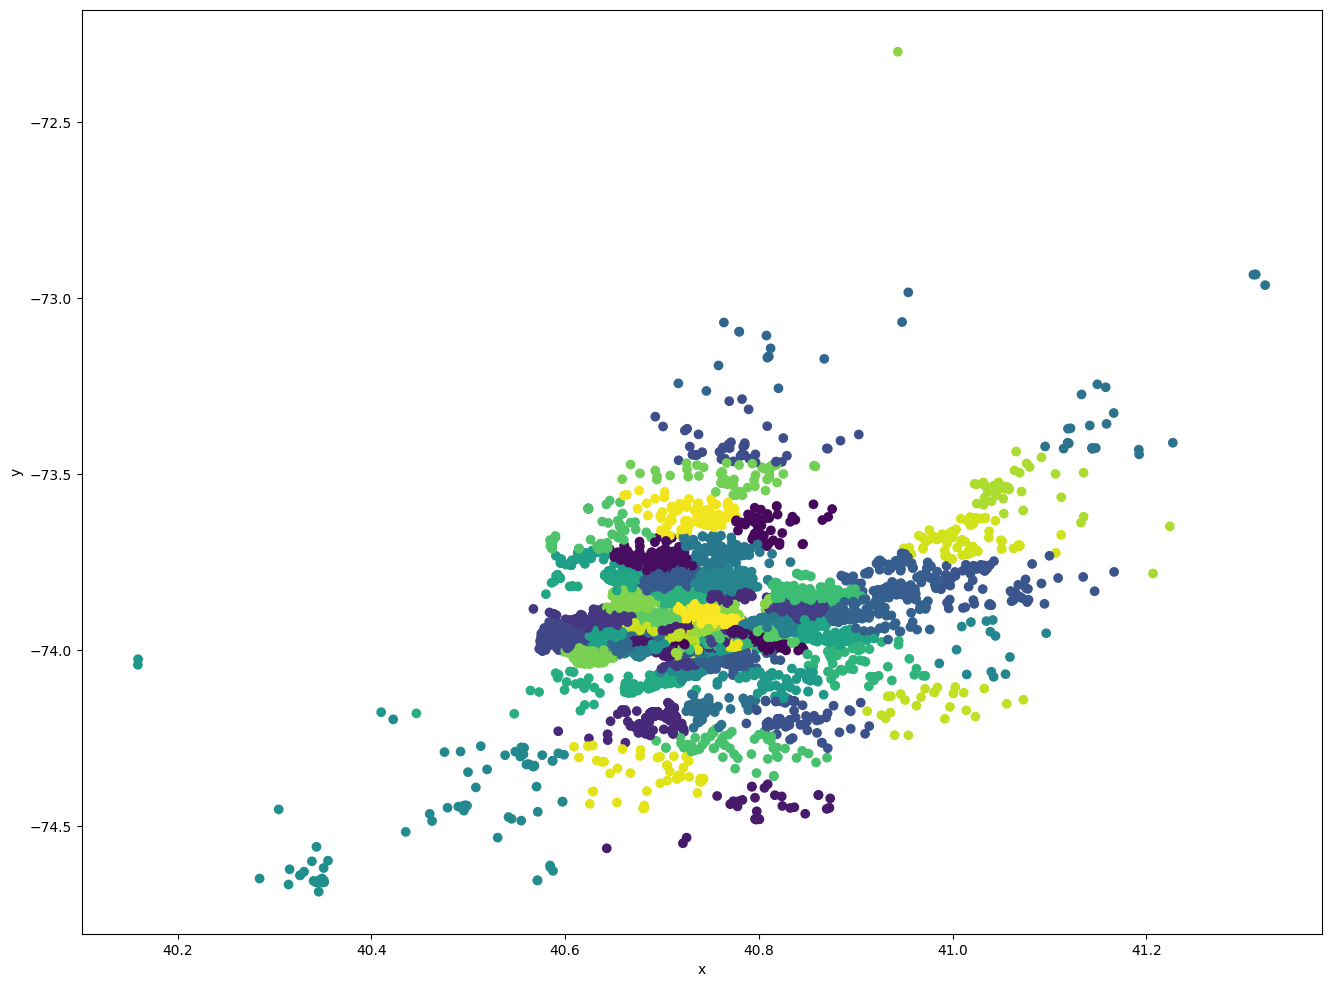

<Figure size 1200x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
pddf_pred = predictDf.toPandas()
pddf_pred.head()
fig = plt.figure(figsize=(16,12))
KmVis= fig.add_subplot(111)
threedee = plt.figure(figsize=(12,10))
KmVis.scatter(pddf_pred.Lat, pddf_pred.Lon,  c=pddf_pred.prediction)
KmVis.set_xlabel('x')
KmVis.set_ylabel('y')

plt.show()

In [ ]:
#save model
kmeansModel.write().overwrite().save("uber-model")
kmeansModelLoded = kmeansModel.load("uber-model")

In [ ]:
df1 = spark.sparkContext.parallelize([
    ("5/1/2014 0:02:00", 40.7521, -73.9914, "B02512"),
    ("5/1/2014 0:06:00", 40.6965, -73.9715, "B02512"),
    ("5/1/2014 0:15:00", 40.7464, -73.9838, "B02512"),
    ("5/1/2014 0:17:00", 40.7463, -74.0011, "B02512"),
    ("5/1/2014 0:17:00", 40.7594, -73.9734, "B02512")]
  ).toDF(["time", "Lat", "Lon", "base"])
df1.show()

+----------------+-------+--------+------+
|            time|    Lat|     Lon|  base|
+----------------+-------+--------+------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|
+----------------+-------+--------+------+



In [ ]:
df2 = assembler.transform(df1)
df2.show()

+----------------+-------+--------+------+------------------+
|            time|    Lat|     Lon|  base|          features|
+----------------+-------+--------+------+------------------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|
+----------------+-------+--------+------+------------------+



In [ ]:
# prediction of sample data set with loaded model
df3 = kmeansModelLoded.transform(df2)
df3.show()

+----------------+-------+--------+------+------------------+----------+
|            time|    Lat|     Lon|  base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|        13|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|        31|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|        56|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|        45|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|        65|
+----------------+-------+--------+------+------------------+----------+




 Running BisectingKMeans for k=10
[ 40.67338224 -74.00971664]
[ 40.72895858 -73.99932375]
[ 40.7074469  -73.95045524]
[ 40.75573583 -73.98877688]
[ 40.75946695 -73.97283934]
[ 40.78529467 -73.9549018 ]
[ 40.65312275 -73.78748791]
[ 40.75806054 -73.53088401]
[ 40.76991201 -73.86483945]
[ 41.00715424 -73.70755688]
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00|40.7311|-73.9888|B02598|[40.7311,-73.9888]|         1|
|5/1/2014 0:02:00|40.7206| -73.989|B02598| [40.7206,-73.989]|         1|
|5/1/2014 0:04:00| 40.708|-74.0143|B02598| [40.708,-74.0143]|         1|
|5/1/2014 0:04:00|40.7187|-74.0059|B02617|[40.7187,-74.0059]|         1|
|5/1/2014 0:04:00|40.7327|  -73.99|B02598|  [40.7327,-73.99]|         1|
+----------------+-------+--------+------+------------------+----------+
only showing top 5 rows

 Si

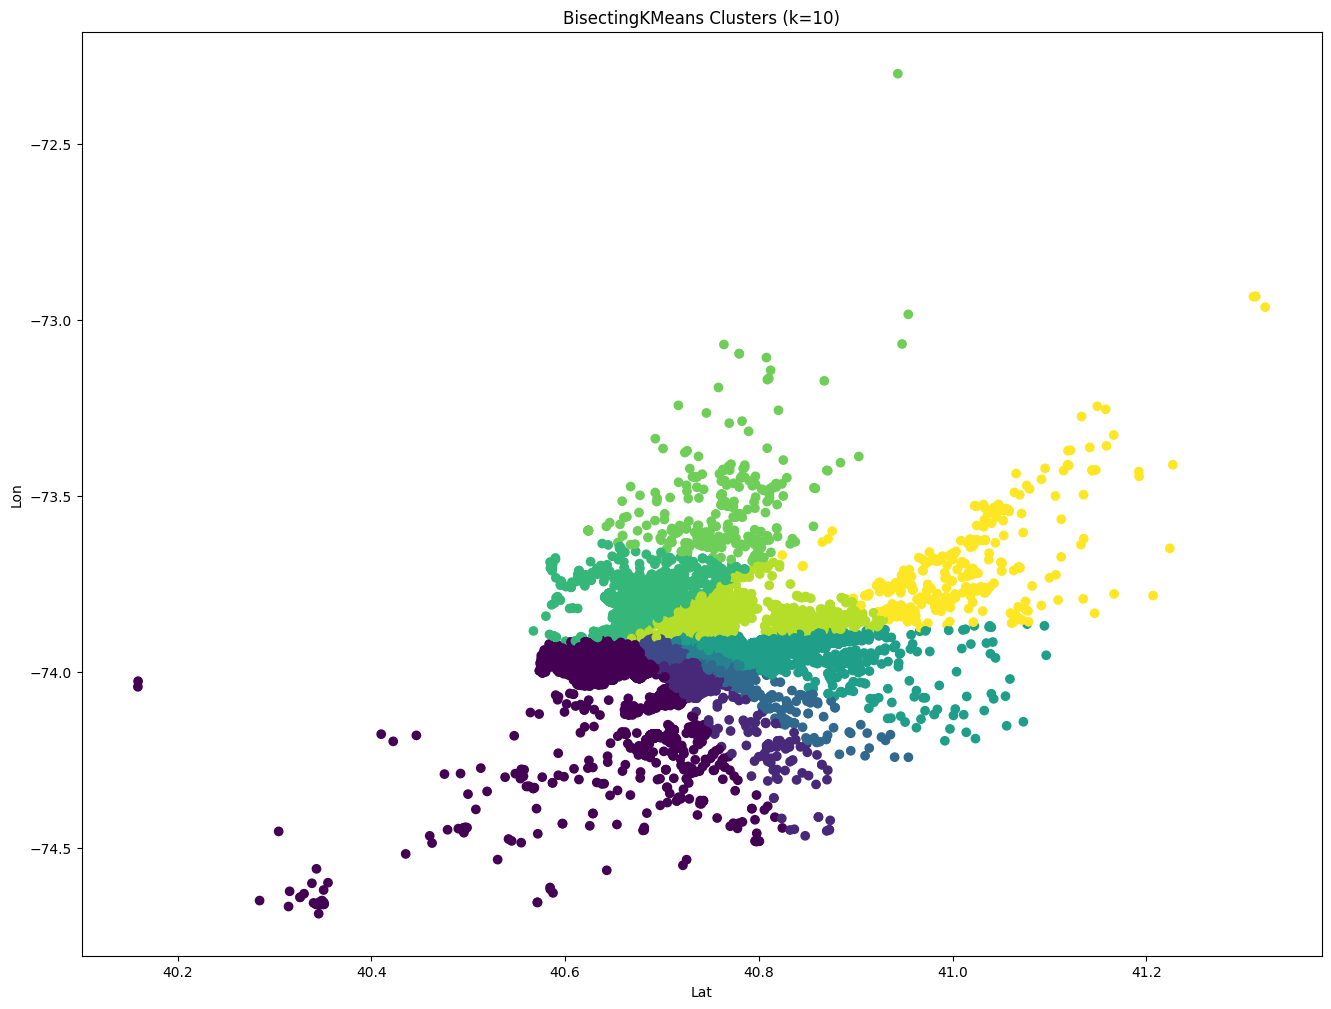


 Running BisectingKMeans for k=30
[ 40.60149329 -74.44669521]
[ 40.69468111 -74.18066591]
[ 40.63514349 -73.96074611]
[ 40.68020567 -73.98381705]
[ 40.7116578  -73.95822212]
[ 40.69712666 -73.93141983]
[ 40.71797552 -74.00607989]
[ 40.7354565 -73.9953266]
[ 40.75324541 -73.98882862]
[ 40.77005729 -73.98569066]
[ 40.73721037 -73.95717607]
[ 40.75800536 -73.97289735]
[ 40.78133736 -73.95965942]
[ 40.76470907 -73.92289567]
[ 40.8510464  -73.92745802]
[ 40.9606428 -74.0428968]
[ 40.65146577 -73.88878387]
[ 40.69251809 -73.83219205]
[ 40.64640707 -73.7834503 ]
[ 40.71786865 -73.74756667]
[ 40.7373622  -73.62200536]
[ 40.77665154 -73.52169846]
[ 40.79001024 -73.33332892]
[ 40.71771502 -73.86754843]
[ 40.75836977 -73.8125117 ]
[ 40.77115009 -73.87000148]
[ 40.85980729 -73.85708286]
[ 40.96132105 -73.80605697]
[ 41.01313861 -73.71434102]
[ 41.0785858  -73.51240909]
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          feat

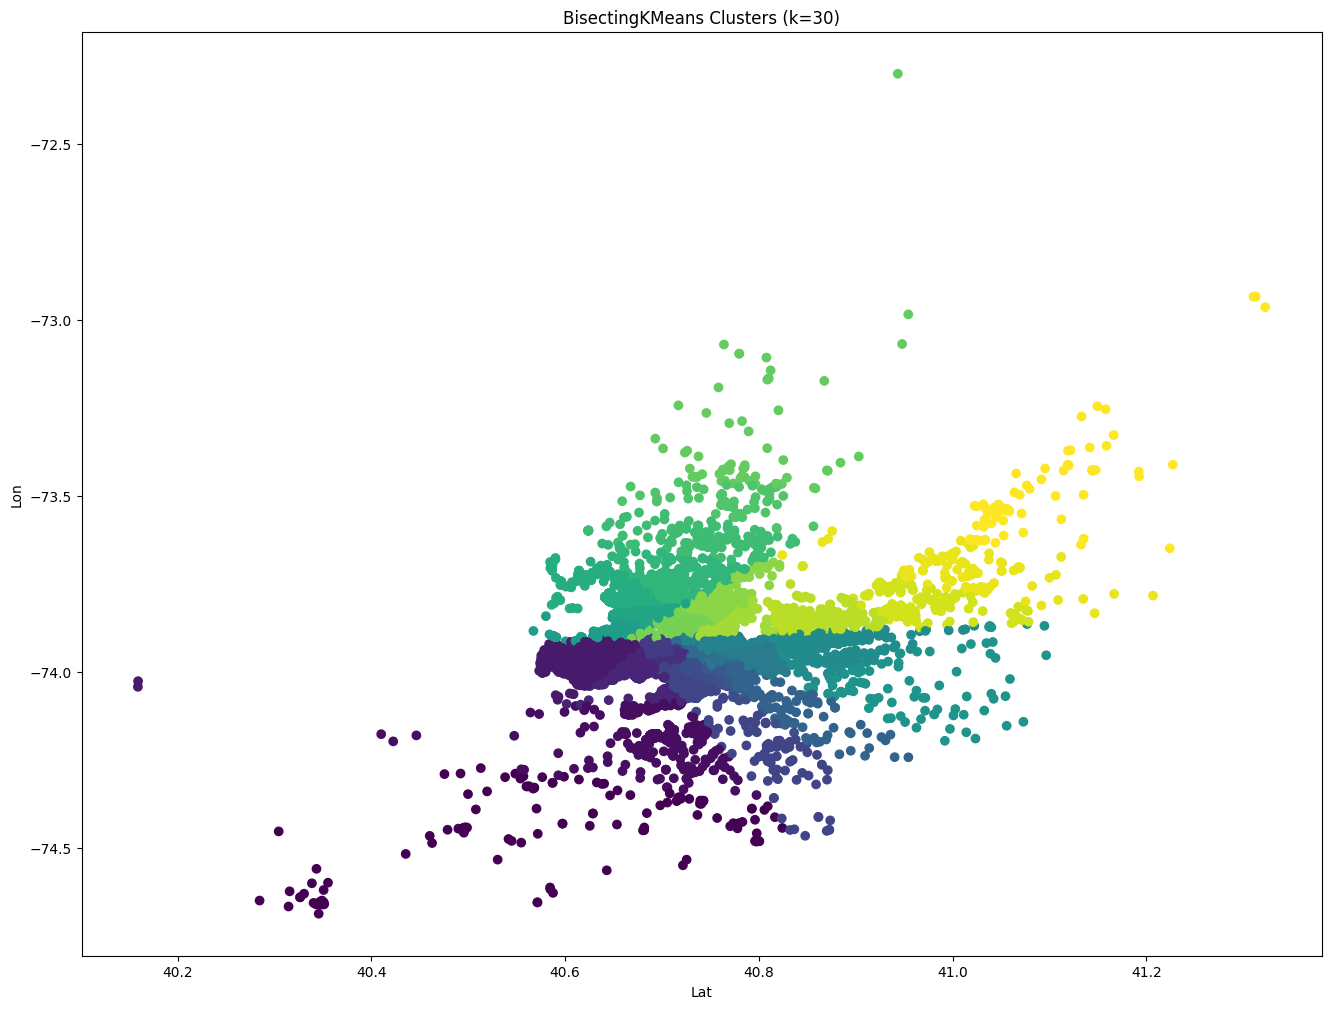

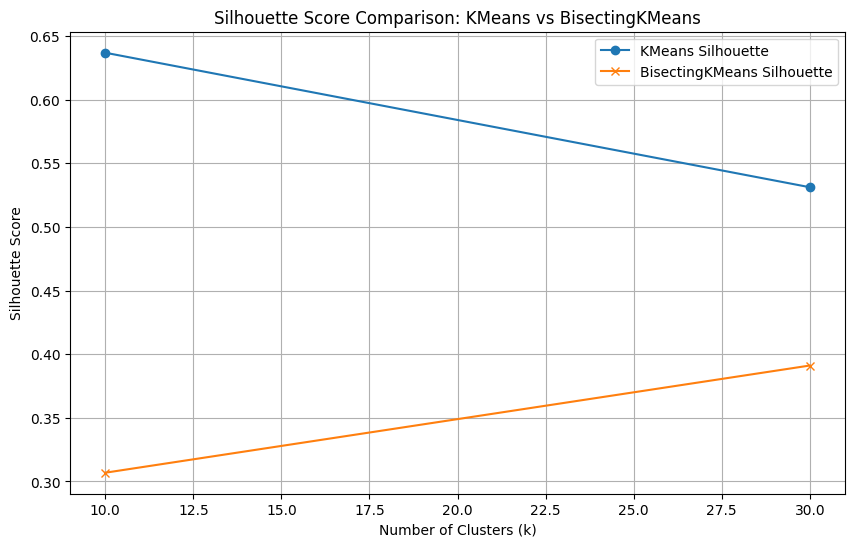

In [ ]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
from pyspark import SparkContext, SparkConf


bisect_silhouettes = []
kmeans_silhouettes = []

cluster_count = [10, 30]

for i in cluster_count:
    print(f"\n Running BisectingKMeans for k={i}")

    # The SparkContext and SparkSession are already created at the beginning of the notebook.
    # Creating a new one here causes the error.
    # if 'spark' in globals():
    #   spark.stop()

    # conf = SparkConf().setAppName("BisectingKMeans").setMaster("local[*]")
    # sc = SparkContext(conf=conf)
    # spark = SparkSession(sc)

    bkmeans = BisectingKMeans()\
        .setK(i)\
        .setSeed(1)\
        .setFeaturesCol("features")\
        .setPredictionCol("prediction")

    bk_model = bkmeans.fit(trainingData)

    for center in bk_model.clusterCenters():
        print(center)

    bk_predictions = bk_model.transform(testData)
    bk_predictions.show(5)

    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(bk_predictions)
    print(" Silhouette Score (BisectingKMeans):", silhouette)
    bisect_silhouettes.append(silhouette)

    # Also calculate KMeans silhouette for comparison and append
    kmeans = KMeans().setK(i).setSeed(1).setFeaturesCol("features").setPredictionCol("prediction")
    kmeansModel = kmeans.fit(trainingData)
    kmeans_predictions = kmeansModel.transform(testData)
    kmeans_silhouette = evaluator.evaluate(kmeans_predictions)
    kmeans_silhouettes.append(kmeans_silhouette)


    # Visualization part unchanged
    pddf_bk = bk_predictions.toPandas()
    fig = plt.figure(figsize=(16,12))
    BkVis = fig.add_subplot(111)
    BkVis.scatter(pddf_bk.Lat, pddf_bk.Lon,  c=pddf_bk.prediction)
    BkVis.set_xlabel('Lat')
    BkVis.set_ylabel('Lon')
    plt.title(f"BisectingKMeans Clusters (k={i})")
    plt.show()

# After the loop, plot the silhouette score comparison
plt.figure(figsize=(10,6))
plt.plot(cluster_count, kmeans_silhouettes, marker='o', label='KMeans Silhouette')
plt.plot(cluster_count, bisect_silhouettes, marker='x', label='BisectingKMeans Silhouette')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Comparison: KMeans vs BisectingKMeans')
plt.legend()
plt.grid(True)
plt.show()

This code performs clustering analysis on Uber trip data using PySpark. It begins by loading the dataset from Google Drive and preprocessing it by selecting latitude and longitude columns, then combines them into feature vectors using VectorAssembler. The data is split into training and testing sets, and KMeans clustering is applied for multiple cluster sizes (k = 10, 30, 50, 70, 90). For each model, cluster centers are printed, predictions are made on the test set, and model performance is evaluated using the Silhouette Score. The clustering results are visualized using Matplotlib. The trained KMeans model is then saved, reloaded, and tested on new sample data. Finally, BisectingKMeans is implemented for comparison with KMeans, and their Silhouette Scores are plotted to evaluate clustering performance across different methods.